# FEM resolution comparison

Compare the standard FEM snapshots with the fine-mesh FEM snapshots. The fine solution is used as the reference for absolute and relative errors.


In [1]:
from pathlib import Path

import numpy as np
from matplotlib import pyplot as plt

from params import hole_r, hole_x, hole_y


In [2]:
results_dir = Path("comparison_results")

fine_snapshot_file = results_dir / "fem_comparison_snapshots_fine.npz"
standard_snapshot_file = results_dir / "fem_comparison_snapshots.npz"

with np.load(fine_snapshot_file) as data:
    points_fine = data["points"]
    times_fine = data["times"]
    u_fine = data["u"]

with np.load(standard_snapshot_file) as data:
    points_standard = data["points"]
    times_standard = data["times"]
    u_standard = data["u"]


In [3]:
if points_fine.shape != points_standard.shape:
    raise ValueError(
        f"Point shape mismatch: fine {points_fine.shape}, "
        f"standard {points_standard.shape}"
    )
if not np.array_equal(points_fine, points_standard):
    raise ValueError("Fine and standard FEM coordinates do not match exactly")

if times_fine.shape != times_standard.shape:
    raise ValueError(
        f"Time shape mismatch: fine {times_fine.shape}, "
        f"standard {times_standard.shape}"
    )
if not np.array_equal(times_fine, times_standard):
    raise ValueError("Fine and standard FEM snapshot times do not match exactly")

if u_fine.shape != u_standard.shape:
    raise ValueError(
        f"Solution shape mismatch: fine {u_fine.shape}, "
        f"standard {u_standard.shape}"
    )
expected_shape = (len(times_fine), len(points_fine))
if u_fine.shape != expected_shape:
    raise ValueError(
        f"Unexpected solution shape {u_fine.shape}; expected {expected_shape}"
    )

for name, values in (
    ("fine points", points_fine),
    ("standard points", points_standard),
    ("fine times", times_fine),
    ("standard times", times_standard),
    ("fine solution", u_fine),
    ("standard solution", u_standard),
):
    if not np.isfinite(values).all():
        raise ValueError(f"{name} contains non-finite values")

# The compatibility checks establish a shared coordinate and time basis.
points = points_fine
times = times_fine


In [4]:
# Reconstruct the regular Cartesian grid from the shared comparison points.
x = np.unique(points[:, 0])
y = np.unique(points[:, 1])
x_grid, y_grid = np.meshgrid(x, y, indexing="xy")

x_indices = np.searchsorted(x, points[:, 0])
y_indices = np.searchsorted(y, points[:, 1])

if not (
    np.array_equal(x[x_indices], points[:, 0])
    and np.array_equal(y[y_indices], points[:, 1])
):
    raise ValueError("Comparison points could not be mapped to the reconstructed grid")


In [5]:
absolute_errors = np.abs(u_standard - u_fine)
relative_l2_percent = np.empty(len(times), dtype=np.float64)

for i in range(len(times)):
    difference_norm = np.linalg.norm(u_standard[i] - u_fine[i])
    reference_norm = np.linalg.norm(u_fine[i])
    if reference_norm > 0.0:
        relative_l2_percent[i] = 100.0 * difference_norm / reference_norm
    else:
        relative_l2_percent[i] = 0.0 if difference_norm == 0.0 else np.inf

for time, relative_error in zip(times, relative_l2_percent):
    print(f"t={time:g}: relative L2 error = {relative_error:.6g}%")


t=0: relative L2 error = 0%
t=1: relative L2 error = 0.016298%
t=2: relative L2 error = 0.0145711%
t=3: relative L2 error = 0.0138876%
t=4: relative L2 error = 0.0136325%
t=5: relative L2 error = 0.0135387%


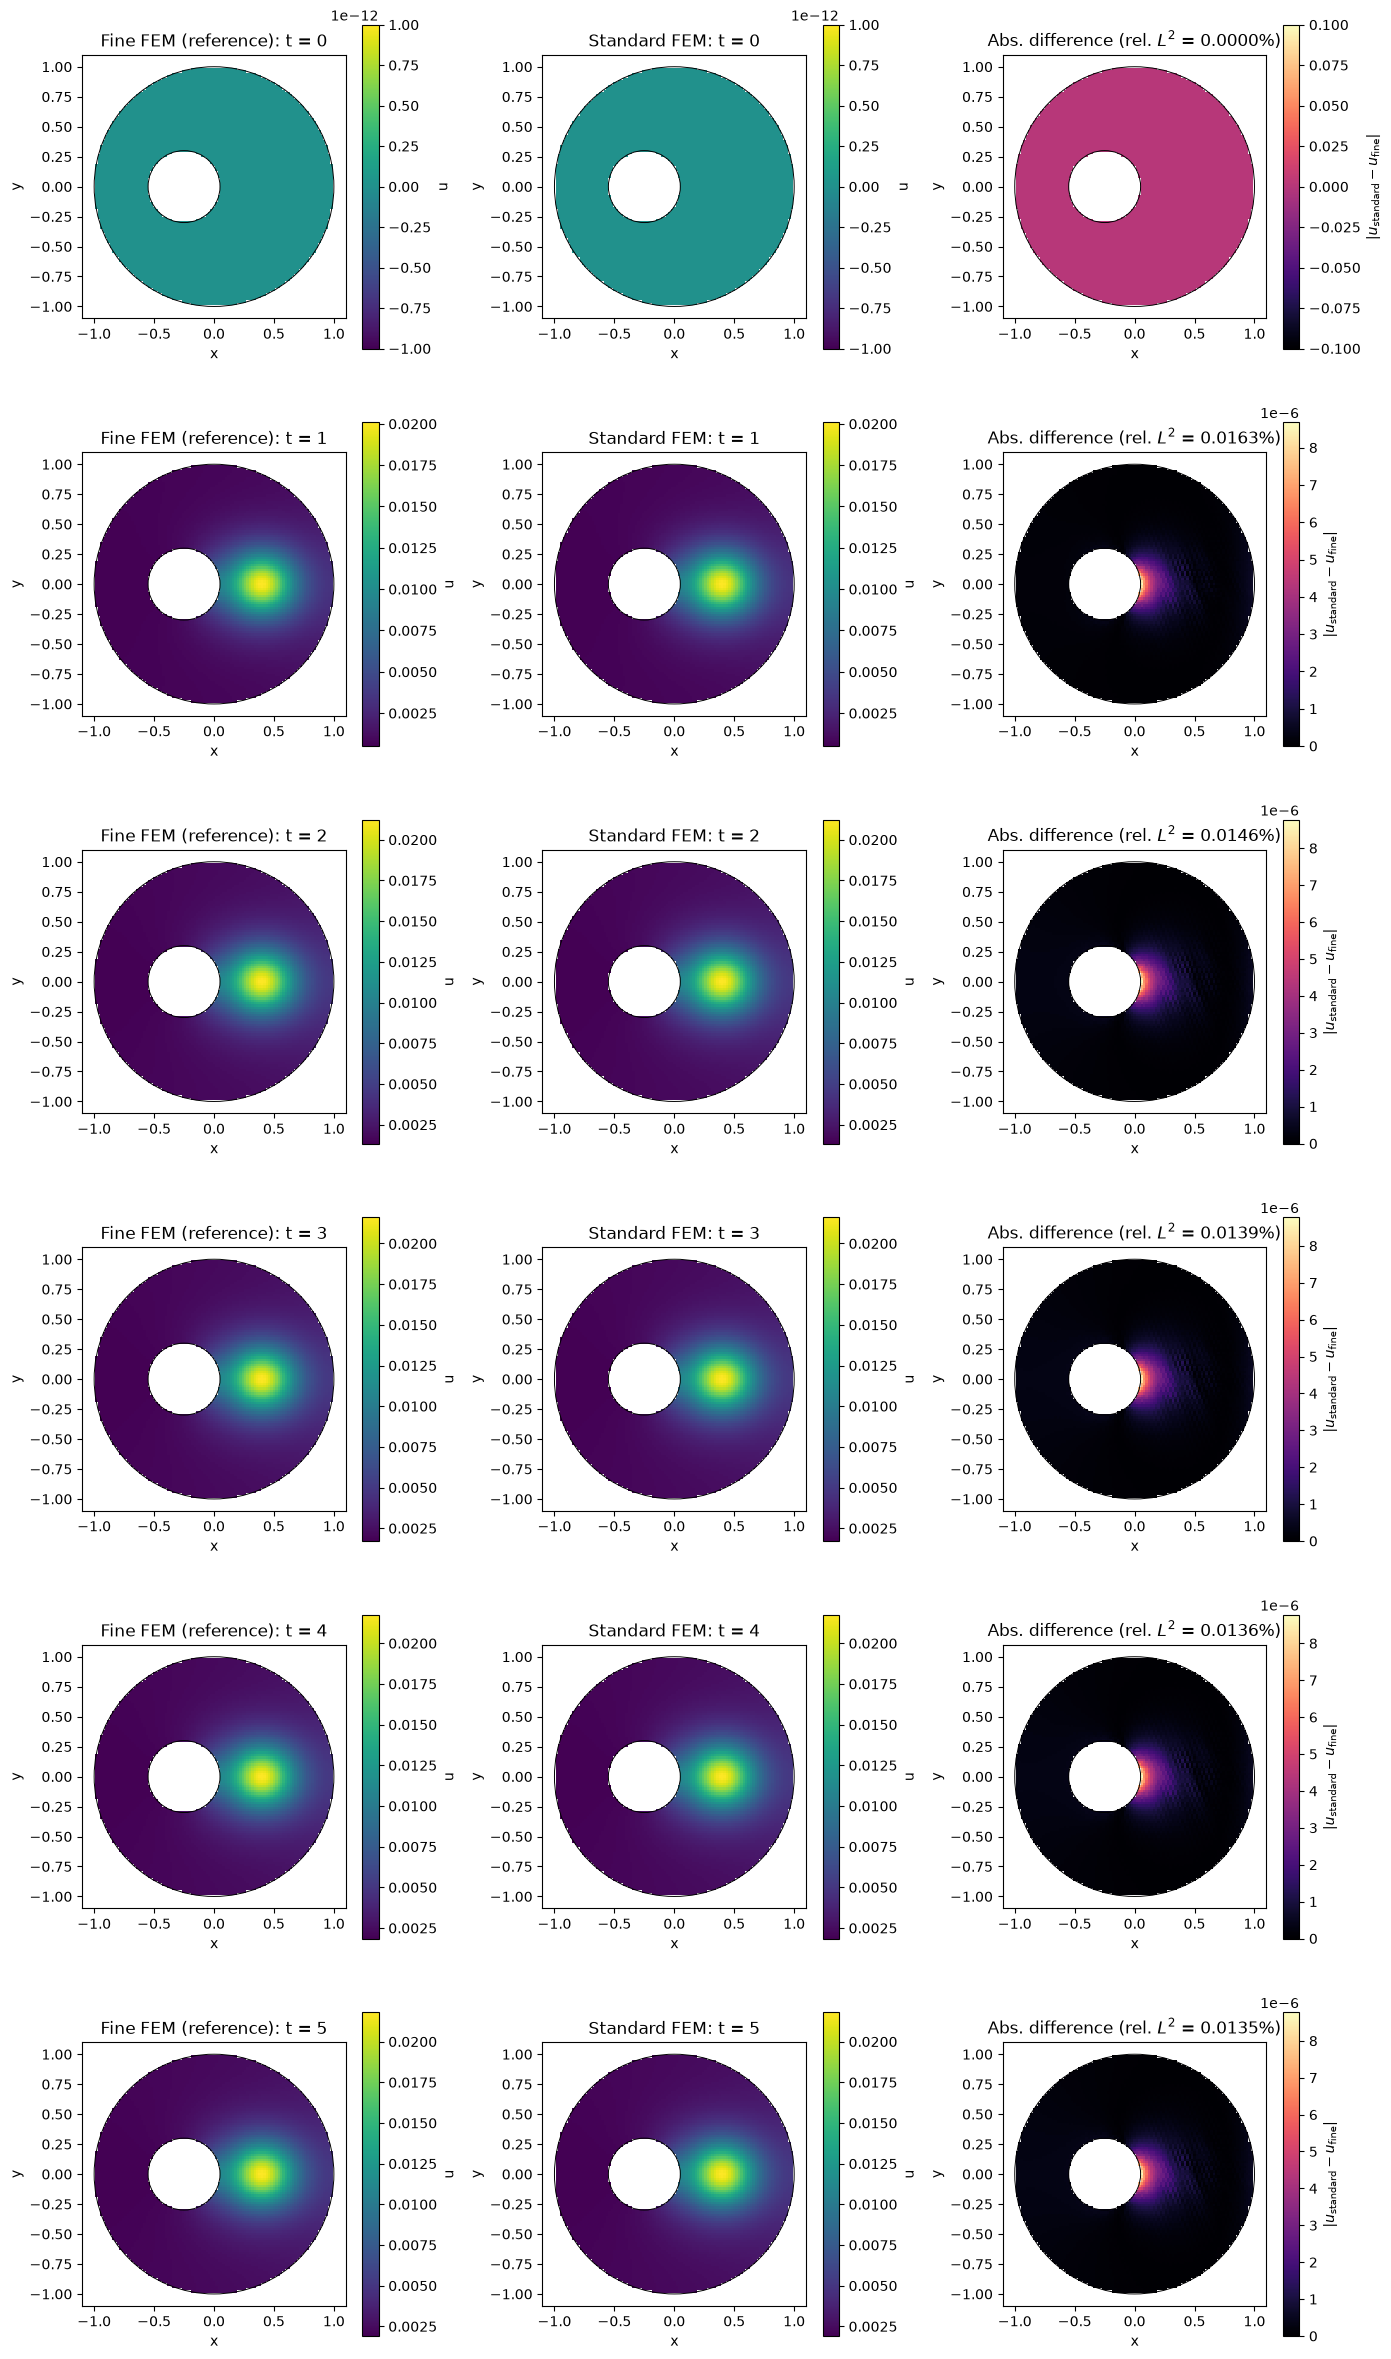

Saved comparison figure to fem_resolution_comparison.png


In [6]:
rows = len(times)
fig, axes = plt.subplots(
    rows,
    3,
    figsize=(14, 4 * rows),
    squeeze=False,
)

for i, time in enumerate(times):
    fine_field = np.full(x_grid.shape, np.nan)
    standard_field = np.full(x_grid.shape, np.nan)
    error_field = np.full(x_grid.shape, np.nan)

    fine_field[y_indices, x_indices] = u_fine[i]
    standard_field[y_indices, x_indices] = u_standard[i]
    error_field[y_indices, x_indices] = absolute_errors[i]

    # Use one colour scale for both solutions at this snapshot.
    combined = np.concatenate((u_fine[i], u_standard[i]))
    value_min = combined.min()
    value_max = combined.max()
    if value_min == value_max:
        padding = max(abs(value_min), 1.0) * 1.0e-12
        value_min -= padding
        value_max += padding

    fine_image = axes[i, 0].pcolormesh(
        x_grid,
        y_grid,
        fine_field,
        shading="auto",
        cmap="viridis",
        vmin=value_min,
        vmax=value_max,
    )
    standard_image = axes[i, 1].pcolormesh(
        x_grid,
        y_grid,
        standard_field,
        shading="auto",
        cmap="viridis",
        vmin=value_min,
        vmax=value_max,
    )
    error_image = axes[i, 2].pcolormesh(
        x_grid,
        y_grid,
        error_field,
        shading="auto",
        cmap="magma",
        vmin=0.0,
    )

    axes[i, 0].set_title(f"Fine FEM (reference): t = {time:g}")
    axes[i, 1].set_title(f"Standard FEM: t = {time:g}")
    axes[i, 2].set_title(
        f"Abs. difference (rel. $L^2$ = {relative_l2_percent[i]:.4f}%)"
    )

    for axis in axes[i]:
        axis.add_patch(
            plt.Circle(
                (0.0, 0.0),
                1.0,
                fill=False,
                color="black",
                linewidth=0.7,
            )
        )
        axis.add_patch(
            plt.Circle(
                (hole_x, hole_y),
                hole_r,
                fill=False,
                color="black",
                linewidth=0.7,
            )
        )
        axis.set(aspect="equal", xlabel="x", ylabel="y")

    fig.colorbar(fine_image, ax=axes[i, 0], label="u")
    fig.colorbar(standard_image, ax=axes[i, 1], label="u")
    fig.colorbar(
        error_image,
        ax=axes[i, 2],
        label=r"$|u_{\mathrm{standard}}-u_{\mathrm{fine}}|$",
    )

fig.tight_layout()
plt.show()

output_figure = Path("fem_resolution_comparison.png")
fig.savefig(output_figure, dpi=180, bbox_inches="tight")
print(f"Saved comparison figure to {output_figure}")
